# Lab 7: Variational Autoencoder (VAE) on MNIST

In this lab, we implement a simple VAE that learns to encode MNIST digits into a latent space using mean (μ) and log-variance (log(σ²)), and then decodes them back to reconstruct the original images.

## Step 1: Import Libraries

In [62]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## Step 2: Set Hyperparameters

In [63]:
# Image size for MNIST is 28x28 = 784 pixels
input_size = 784
hidden_size = 512
latent_size = 50
batch_size = 128
num_epochs = 10
learning_rate = 0.005

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Step 3: Load MNIST Dataset

In [64]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Training samples: 60000
Test samples: 10000


## Step 4: Define the VAE Model

The VAE has three parts:
- **Encoder**: Takes the input image and outputs two vectors — mean (μ) and log-variance (log(σ²))
- **Reparameterization Trick**: Samples a latent vector z = μ + σ * ε, where ε ~ N(0, 1)
- **Decoder**: Takes the latent vector z and reconstructs the image

In [65]:
class VAE(nn.Module):
    def __init__(self, input_size, hidden_size, latent_size):
        super(VAE, self).__init__()
        
        # ---------- Encoder (2 hidden layers) ----------
        self.fc1 = nn.Linear(input_size, hidden_size)     # 784 → 512
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)  # 512 → 256
        self.fc_mu = nn.Linear(hidden_size // 2, latent_size)     # 256 → 30
        self.fc_logvar = nn.Linear(hidden_size // 2, latent_size) # 256 → 30
        
        # ---------- Decoder (2 hidden layers) ----------
        self.fc3 = nn.Linear(latent_size, hidden_size // 2)  # 30 → 256
        self.fc4 = nn.Linear(hidden_size // 2, hidden_size)  # 256 → 512
        self.fc5 = nn.Linear(hidden_size, input_size)        # 512 → 784
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def encode(self, x):
        h = self.relu(self.fc1(x))
        h = self.relu(self.fc2(h))     # extra layer
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon
        return z
    
    def decode(self, z):
        h = self.relu(self.fc3(z))
        h = self.relu(self.fc4(h))     # extra layer
        reconstruction = self.sigmoid(self.fc5(h))
        return reconstruction
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

## Step 5: Define the Loss Function

VAE loss = Reconstruction Loss + KL Divergence
- **Reconstruction Loss**: How well the decoder output matches the original input (using BCE)
- **KL Divergence**: Measures how close the learned distribution is to a standard normal distribution N(0,1)

In [66]:
def vae_loss(reconstruction, x, mu, logvar):
    # Reconstruction loss (Binary Cross Entropy)
    bce_loss = nn.functional.binary_cross_entropy(reconstruction, x, reduction='sum')
    
    # KL Divergence: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return bce_loss + kl_loss

## Step 6: Create Model and Optimizer

In [67]:
model = VAE(input_size, hidden_size, latent_size).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(model)

VAE(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc_mu): Linear(in_features=256, out_features=50, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=50, bias=True)
  (fc3): Linear(in_features=50, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=512, bias=True)
  (fc5): Linear(in_features=512, out_features=784, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


## Step 7: Training Loop

In [68]:
train_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for images, _ in train_loader:
        # Flatten the images from (batch, 1, 28, 28) to (batch, 784)
        images = images.view(-1, input_size).to(device)
        
        # Forward pass
        reconstruction, mu, logvar = model(images)
        loss = vae_loss(reconstruction, images, mu, logvar)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_dataset)
    train_losses.append(avg_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}')

Epoch [1/10], Average Loss: 167.9333
Epoch [2/10], Average Loss: 131.4209
Epoch [3/10], Average Loss: 124.6697
Epoch [4/10], Average Loss: 121.6581
Epoch [5/10], Average Loss: 120.0213
Epoch [6/10], Average Loss: 118.9073
Epoch [7/10], Average Loss: 118.2141
Epoch [8/10], Average Loss: 117.6620
Epoch [9/10], Average Loss: 117.2684
Epoch [10/10], Average Loss: 116.8476


## Step 8: Plot Training Loss

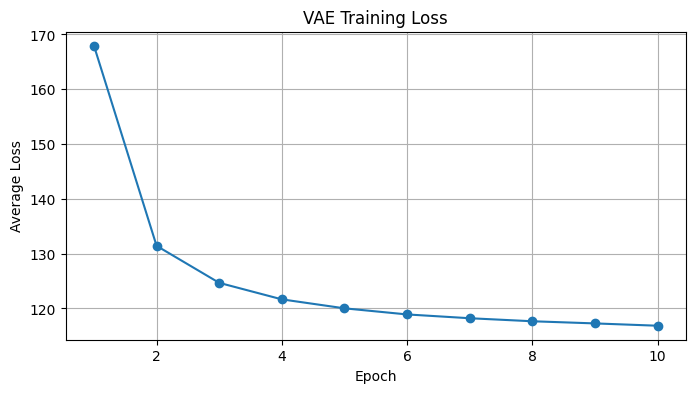

In [69]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('VAE Training Loss')
plt.grid(True)
plt.show()

## Step 9: Test the Model — Reconstruct Images

We pass some test images through the VAE and compare the original with the reconstruction.

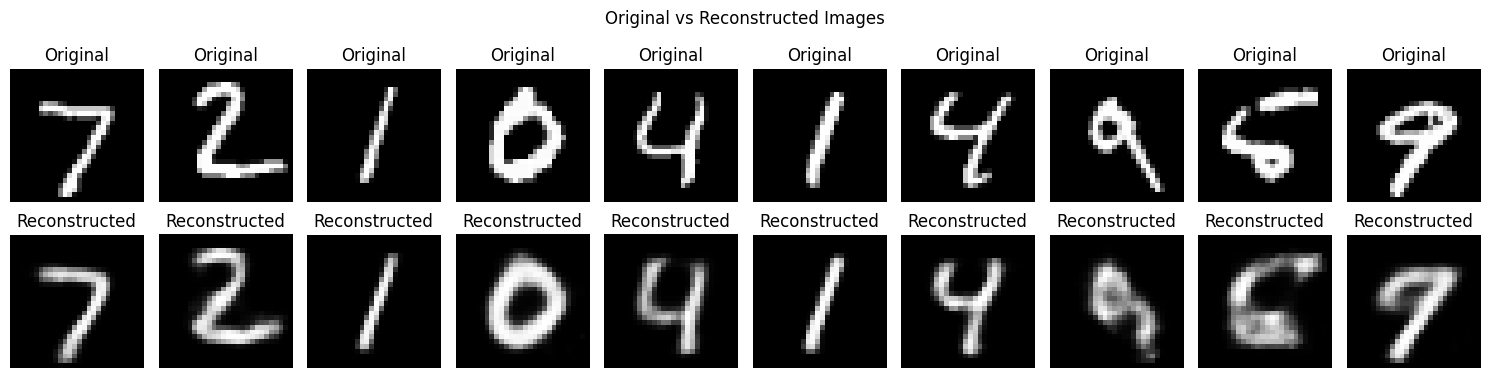

In [70]:
model.eval()

# Get one batch of test images
test_images, _ = next(iter(test_loader))
test_images_flat = test_images.view(-1, input_size).to(device)

with torch.no_grad():
    reconstructed, _, _ = model(test_images_flat)

# Move to CPU for plotting
test_images_flat = test_images_flat.cpu()
reconstructed = reconstructed.cpu()

# Show 10 original vs reconstructed images
n = 10
plt.figure(figsize=(15, 4))
for i in range(n):
    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(test_images_flat[i].view(28, 28), cmap='gray')
    plt.title('Original')
    plt.axis('off')
    
    # Reconstructed
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].view(28, 28), cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')

plt.suptitle('Original vs Reconstructed Images')
plt.tight_layout()
plt.show()

## Step 10: Generate New Images from Latent Space

We sample random latent vectors from N(0,1) and pass them through the decoder to generate new digit images.

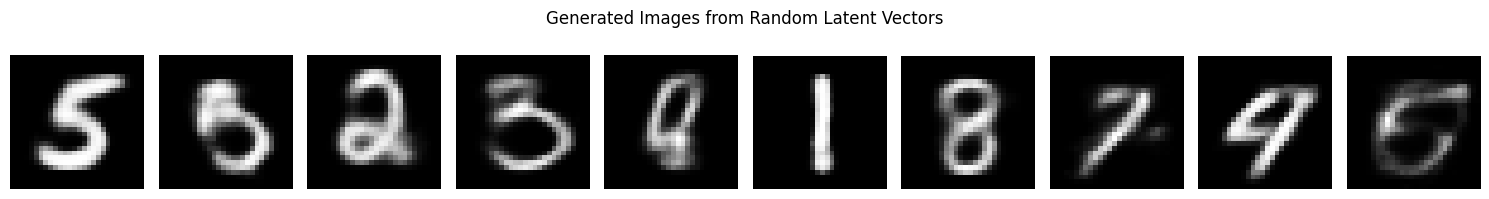

In [71]:
with torch.no_grad():
    # Sample random latent vectors from standard normal distribution
    z = torch.randn(10, latent_size).to(device)
    
    # Decode them into images
    generated = model.decode(z).cpu()

plt.figure(figsize=(15, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(generated[i].view(28, 28), cmap='gray')
    plt.axis('off')

plt.suptitle('Generated Images from Random Latent Vectors')
plt.tight_layout()
plt.show()

## Step 11: Evaluate on Test Set

In [72]:
model.eval()
test_loss = 0

with torch.no_grad():
    for images, _ in test_loader:
        images = images.view(-1, input_size).to(device)
        reconstruction, mu, logvar = model(images)
        test_loss += vae_loss(reconstruction, images, mu, logvar).item()

avg_test_loss = test_loss / len(test_dataset)
print(f'Average Test Loss: {avg_test_loss:.4f}')

Average Test Loss: 118.0924
